# Day 3 · Lab — Fine-tune a Tiny Model
**Goal:** make the Day-3 decisions concrete. We fine-tune **distilGPT2** on customer-support
text, watch the **loss curve**, deliberately trigger a **loss spike** and recover, and compare
**generations before vs after**. Finally, a quick look at **reduced precision** for deployment.

> Small model, few steps — runs on a laptop **CPU** in a few minutes. Model is cached locally.
> A pre-baked loss curve is saved alongside in case the live run drifts.

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

torch.manual_seed(7); np.random.seed(7)
NAME = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(NAME)
tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(NAME)
n_params = sum(p.numel() for p in model.parameters())
print('distilGPT2 params: %.1fM' % (n_params / 1e6))

distilGPT2 params: 81.9M


## 1. Baseline — generate before fine-tuning

In [2]:
def generate(prompt, max_new_tokens=30):
    ids = tok(prompt, return_tensors='pt')
    with torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tok.eos_token_id)
    return tok.decode(out[0], skip_special_tokens=True)

PROMPT = 'Customer: I need help with my refund.\nSupport:'
print('BEFORE:\n', generate(PROMPT))

BEFORE:
 Customer: I need help with my refund.
Support:
I am a customer of the company. I am a customer of the company. I am a customer of the company. I am a customer of


## 2. Build a small fine-tuning set

We turn each support ticket into **one** `Customer: … / Support: …` example, then
**pad** every example to a common length so a batch is a clean rectangle.

Each row is exactly one demonstration — the SFT signal from the lecture: *show the model
a prompt and the ideal response, and let it learn the behaviour.*

In [ ]:
DATA = next((p for p in ('datasets', '../datasets', '../../datasets') if os.path.isdir(p)), None)
if DATA is None:
    raise FileNotFoundError("Could not find a datasets directory. Tried: datasets, ../datasets, ../../datasets")
df = pd.read_csv(os.path.join(DATA, 'support_tickets_classification.csv'))

# one ticket -> one training example (ends with EOS so the model learns to STOP)
texts = ['Customer: ' + t + '\nSupport: Happy to help with your ' + c.lower() + ' request.' + tok.eos_token
         for t, c in zip(df['text'], df['category'])]

# PAD every example to the same length -> a rectangular [n_examples, seq_len] batch
enc = tok(texts, padding=True, truncation=True, max_length=64, return_tensors='pt')
input_ids = enc['input_ids']          # the token ids                (Day 2: text -> tokens -> ids)
attn      = enc['attention_mask']     # 1 = real token, 0 = padding  (Day 2: the attention mask)

#print(enc)

# labels are the next-token targets scored by cross-entropy (Day 1 & 2).
# -100 means 'ignore this position', so we never train the model to predict padding.
labels = input_ids.clone()
labels[attn == 0] = -100

print('examples:', tuple(input_ids.shape), '| padded to', input_ids.shape[1], 'tokens')

{'input_ids': tensor([[44939,    25,   765,  ..., 50256, 50256, 50256],
        [44939,    25,   703,  ..., 50256, 50256, 50256],
        [44939,    25,  2198,  ..., 50256, 50256, 50256],
        ...,
        [44939,    25,   703,  ..., 50256, 50256, 50256],
        [44939,    25,   314,  ..., 50256, 50256, 50256],
        [44939,    25,  6829,  ..., 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}
examples: (640, 36) | padded to 36 tokens


> **Concept check — padding, and what these three tensors are**
>
> Training runs on rectangular batches, but our tickets have different lengths. Two ways to fix that:
> - **Packing** — glue all tickets into one long stream and cut fixed-size blocks. Zero wasted compute, but
>   example boundaries vanish (a block can span two tickets). Great for *pretraining*, confusing for a first fine-tune.
> - **Padding** (what we use) — keep **one example per row** and fill the short ones with a pad token. A little
>   wasted compute, but each row is exactly one Customer→Support demo. Clearer, and the standard way to do SFT.
>
> The three tensors we just built:
> - **`input_ids`** — the tokenized text. This is the tokenization step from **Day 2** (text → tokens → ids).
> - **`attention_mask`** — `1` for real tokens, `0` for padding. It is the **same attention mask from Day 2**:
>   it tells self-attention to ignore the pad positions so they can't affect the real tokens.
> - **`labels`** with `-100` — the next-token targets scored by **cross-entropy (Day 1 & Day 2)**. Marking pad
>   positions `-100` drops them from the loss, so the model is never trained to predict padding.

## 3. Train — the canonical loop (with a deliberate loss spike)

Same loop as Day 1 — forward → loss → backprop → step (the model returns the loss for us).
We log the **per-step loss**, and around steps 40–45 we **crank the learning rate** on purpose.
This time the spike is large enough that the run **does not recover on its own** — a very real
failure mode, not a gentle wobble.

**Good practice — keep the best checkpoint.** As we train we snapshot the best-scoring weights and
reload them at the end. So even though the spike wrecks the tail of the run, we still ship the good
pre-spike model. Same idea as **early stopping from Day 1** — and here it's what saves us.

### Exercise — fill in the four training steps


In [16]:
import copy
opt = torch.optim.AdamW(model.parameters(), lr=5e-4)
BATCH, STEPS = 8, 70
BASE_LR, SPIKE_LR = 5e-4, 1.5e-2        # a big spike: the run does NOT recover on its own
losses, lrs = [], []
best_loss, best_state, best_step = float('inf'), None, -1   # keep the best checkpoint we ever see

model.train()
for step in range(STEPS):
    lr = SPIKE_LR if 40 <= step < 45 else BASE_LR   # deliberate spike window
    for g in opt.param_groups:
        g['lr'] = lr
    idx = torch.randint(0, len(input_ids), (BATCH,))
    b_ids, b_attn, b_labels = input_ids[idx], attn[idx], labels[idx]
    # the four-step loop from Day 1 -
    model.zero_grad()
    out = model(input_ids=b_ids, attention_mask=b_attn, labels=b_labels)
    loss = out.loss
    loss.backward()
    opt.step()
    losses.append(loss.item()); lrs.append(lr)
    # good practice (given): snapshot the best weights so a later spike can't ruin the final model
    if loss.item() < best_loss:
        best_loss, best_step = loss.item(), step
        best_state = copy.deepcopy(model.state_dict())
    if step % 10 == 0 or 38 <= step <= 47:          # print the spike window in detail
        print('step %02d  lr=%.0e  loss=%.3f' % (step, lr, loss.item()))

# restore the best checkpoint (early-stopping style): the spike wrecked the end of the run,
# but we ship the best weights we ever saw
model.load_state_dict(best_state)
print('restored best checkpoint from step %d (loss %.3f)' % (best_step, best_loss))


step 00  lr=5e-04  loss=1.046
step 10  lr=5e-04  loss=0.861
step 20  lr=5e-04  loss=0.778
step 30  lr=5e-04  loss=0.665
step 38  lr=5e-04  loss=1.010
step 39  lr=5e-04  loss=0.977
step 40  lr=1e-02  loss=0.854
step 41  lr=1e-02  loss=5.960
step 42  lr=1e-02  loss=11.117
step 43  lr=1e-02  loss=11.642
step 44  lr=1e-02  loss=8.324
step 45  lr=5e-04  loss=7.383
step 46  lr=5e-04  loss=7.315
step 47  lr=5e-04  loss=6.575
step 50  lr=5e-04  loss=5.938
step 60  lr=5e-04  loss=4.919
restored best checkpoint from step 30 (loss 0.665)


## 4. The loss curve — spot the spike

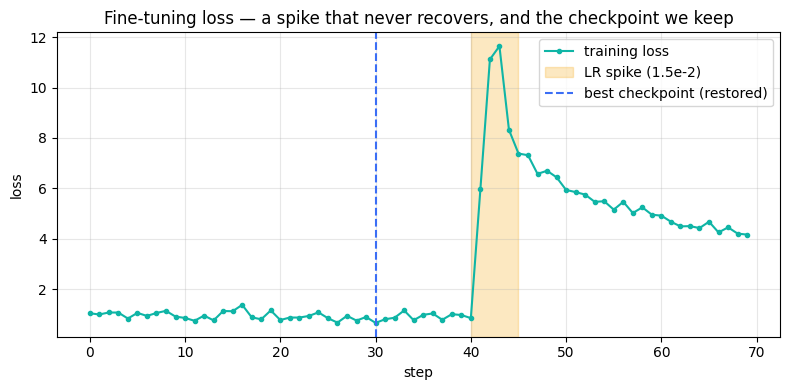

before spike: 0.960 | peak during: 11.642 | final: 4.352  ->  we ship best checkpoint = 0.665


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#0FB5A6', marker='o', ms=3, label='training loss')
ax.axvspan(40, 45, color='#F6A609', alpha=0.25, label='LR spike (1.5e-2)')
ax.axvline(best_step, color='#3B6EF5', ls='--', lw=1.5, label='best checkpoint (restored)')
ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.set_title('Fine-tuning loss — a spike that never recovers, and the checkpoint we keep')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day3_loss_curve_prebaked.png', dpi=110)   # fallback artifact
plt.show()
print('before spike: %.3f | peak during: %.3f | final: %.3f  ->  we ship best checkpoint = %.3f'
      % (np.mean(losses[35:40]), np.max(losses[40:45]), np.mean(losses[65:70]), best_loss))


**Diagnosis:** the loss explodes when the learning rate is too high, and here it **never comes
back** — the tail of the run is ruined. In real training this comes from an LR that's too high, a
bad data batch, or numerical overflow; the fixes are a lower LR, a warm-up, gradient clipping, or
skipping the batch. The reason it didn't sink us this time: we snapshotted the **best checkpoint**
(blue dashed line) and reloaded it, so the model we actually ship is the good pre-spike one — not
the wreckage at the end.


## 5. Generate after fine-tuning

In [18]:
model.eval()
print('AFTER:\n', generate(PROMPT))

AFTER:
 Customer: I need help with my refund.
Support: Happy to help with your refund request.


## 6. Deploy cheaper — reduced precision
Production models are compressed. The simplest lever is **reduced precision**: storing weights in
fp16 instead of fp32 roughly **halves** the model size (int8 dynamic quantization goes further on
Linear-heavy models).

In [ ]:
import io
def size_mb(m):
    buf = io.BytesIO(); torch.save(m.state_dict(), buf); return buf.tell() / 1e6

fp32 = size_mb(model)
half = size_mb(model.half())
model.float()  # restore
print('fp32 size: %.1f MB' % fp32)
print('fp16 size: %.1f MB  (~%.0f%% smaller)' % (half, 100 * (1 - half / fp32)))

### Does shrinking hurt quality?

Halving the size only helps if the model still works. We check the fp16 model two ways — its
**loss** on real data (the same cross-entropy from Days 1–2) and a **sample reply** — against the
full-precision model we just fine-tuned.

> Heads-up: fp16 math is *emulated* on CPU, so this cell is slow here (~1 min). On real serving
> hardware fp16 is both **smaller and faster** — on our CPU we're only proving the size-vs-quality
> trade, not speed.


In [ ]:
model.float()   # the full-precision fine-tuned model we ship

# --- quality check: does fp16 (half the size) still compute the same thing? ---
EVAL = 8   # a small eval sample: one fp16 forward is slow on CPU, so keep it tiny

@torch.no_grad()
def eval_loss(m):
    logits = m(input_ids=input_ids[:EVAL], attention_mask=attn[:EVAL]).logits.float()
    sl = logits[:, :-1, :].reshape(-1, logits.size(-1))
    tl = labels[:EVAL][:, 1:].reshape(-1)
    return torch.nn.functional.cross_entropy(sl, tl, ignore_index=-100).item()

loss_fp32 = eval_loss(model)
model_fp16 = copy.deepcopy(model).half()          # the quantized (half-precision) model
loss_fp16 = eval_loss(model_fp16)
print('eval loss   fp32=%.4f   fp16=%.4f   (change %+.4f)' % (loss_fp32, loss_fp16, loss_fp16 - loss_fp32))

# same prompt, both precisions - the reply should read the same
def reply(m):
    m.eval(); ids = tok(PROMPT, return_tensors='pt')
    with torch.no_grad():
        o = m.generate(**ids, max_new_tokens=20, do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(o[0], skip_special_tokens=True)
print('\nfp32 >', reply(model))
print('fp16 >', reply(model_fp16))

# the quantized model lands on the SAME low loss the run converged to
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#0FB5A6', marker='o', ms=3, alpha=0.6, label='training loss (fp32)')
ax.axhline(loss_fp32, color='#0FB5A6', ls='-',  lw=1.5, label='fp32 eval loss = %.3f' % loss_fp32)
ax.axhline(loss_fp16, color='#3B6EF5', ls='--', lw=1.8, label='fp16 eval loss = %.3f  (half the size)' % loss_fp16)
ax.set_ylim(0, max(3.0, loss_fp16 * 1.2))
ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.set_title('fp16 lands at the same low loss as fp32 - quality survives compression')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


**Takeaway:** fine-tuning is the same training loop you already know — the craft is in the data,
the learning rate, and diagnosing instability. Compression (precision, quantization, distillation,
pruning) is how you make the result cheap enough to ship. Week 2 goes deep on PEFT/LoRA.